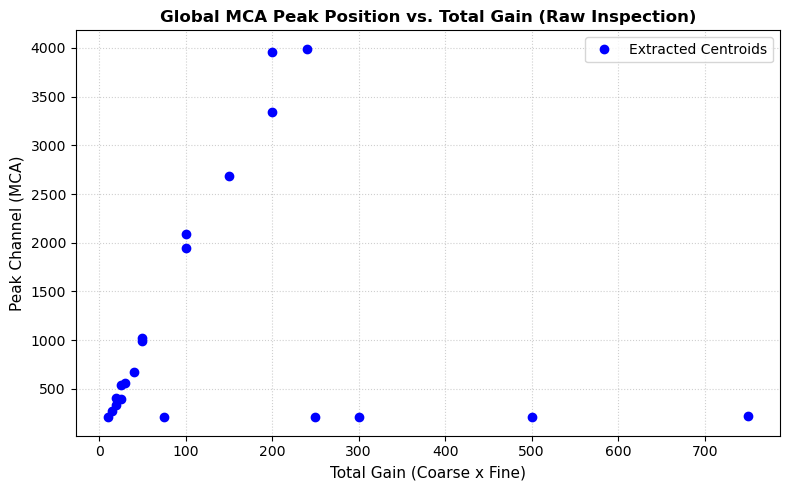

=== Unsaturated Linear Domain Parameters (Total Gain <= 200) ===
Slope (a): 18.30919 +/- 0.60841 [Channels / Total Gain]
Intercept (b): 31.96942 +/- 57.15521 [Channels]
R-squared (R^2): 0.985848
Extracted System Error (sigma_sys): 150.231 channels



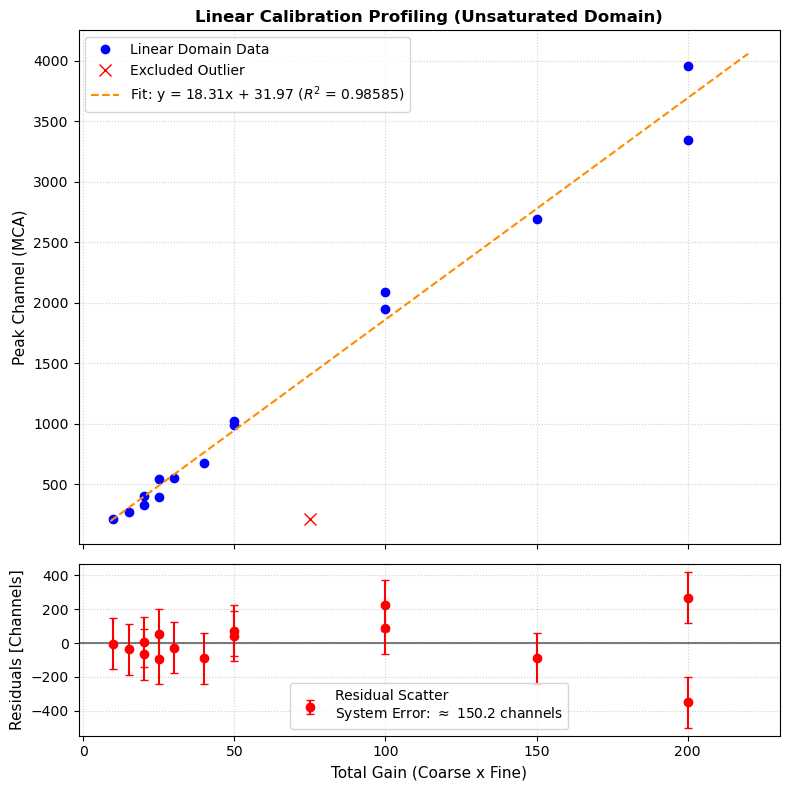

In [21]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Directory path
folder_path = r"C:\Users\chens\OneDrive\שולחן העבודה\School stuff\מסת ניוטרינו\data\attachments\gain"

def linear_model(x, slope, intercept):
    return slope * x + intercept

def gaussian_model(x, amp, mu, sigma):
    return amp * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

def extract_peak_gaussian(filepath):
    try:
        counts = []
        start_reading = False
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if "0 4096" in line:
                    start_reading = True
                    continue
                if start_reading:
                    counts.append(float(line.strip()))
        
        if not counts: return None
        counts = np.array(counts)
        channels = np.arange(len(counts))
        
        raw_max = np.argmax(counts)
        window = 30
        start_idx = max(0, raw_max - window)
        end_idx = min(len(counts), raw_max + window)
        
        x_window = channels[start_idx:end_idx]
        y_window = counts[start_idx:end_idx]
        
        initial_guess = [counts[raw_max], raw_max, 10.0]
        popt, _ = curve_fit(gaussian_model, x_window, y_window, p0=initial_guess, maxfev=10000)
        return popt[1] 
    except Exception:
        return np.argmax(counts) if 'counts' in locals() and counts.size > 0 else None

# --- STEP 1: Parse all files and extract raw centroids ---
mca_x = []
mca_y = []

pattern = re.compile(r"gain\s+(\d+)\s+(\d+(?:_\d+)?)")

for filename in os.listdir(folder_path):
    if not filename.endswith('.txt'): continue
    base_name = os.path.splitext(filename)[0]
    filepath = os.path.join(folder_path, filename)
    
    match = pattern.search(base_name)
    if match:
        try:
            coarse_val = float(match.group(1))
            fine_val = float(match.group(2).replace('_', '.'))
            total_gain = coarse_val * fine_val
            
            peak = extract_peak_gaussian(filepath)
            if peak is not None:
                mca_x.append(total_gain)
                mca_y.append(peak)
        except Exception:
            pass

x_all = np.array(mca_x, dtype=float)
y_all = np.array(mca_y, dtype=float)

# Sort all data points
sort_idx_all = np.argsort(x_all)
x_all, y_all = x_all[sort_idx_all], y_all[sort_idx_all]

# =========================================================================
# GRAPH 1: Raw Global Data (To demonstrate saturation boundaries)
# =========================================================================
plt.figure(figsize=(8, 5))
plt.plot(x_all, y_all, color='blue', marker='o', linestyle='', label='Extracted Centroids')
plt.xlabel("Total Gain (Coarse x Fine)", fontsize=11)
plt.ylabel("Peak Channel (MCA)", fontsize=11)
plt.title("Global MCA Peak Position vs. Total Gain (Raw Inspection)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("gain_raw_data.pdf", format='pdf', bbox_inches='tight')
plt.show()


# --- STEP 2: Filter data for the linear domain and exclude the outlier ---
# CRITICAL: Change this number to the EXACT total gain value of your outlier!
OUTLIER_GAIN = 75.0  

# Logical mask: excludes both the saturation region and the outlier
linear_mask = (x_all <= 200) & (x_all != OUTLIER_GAIN)

x_linear = x_all[linear_mask]
y_linear = y_all[linear_mask]


# =========================================================================
# GRAPH 2: Linear Domain Analysis & Systematic Error Back-Engineering
# =========================================================================
if len(x_linear) >= 2:
    # Perform linear fit only on valid unsaturated points (excluding the outlier)
    popt, pcov = curve_fit(linear_model, x_linear, y_linear)
    slope, intercept = popt
    slope_err, intercept_err = np.sqrt(np.diagonal(pcov))
    
    residuals = y_linear - linear_model(x_linear, *popt)
    
    # R-squared calculation
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y_linear - np.mean(y_linear)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 1.0
    
    # Back-engineer systematic uncertainty (sigma_sys) via chi_sq_red = 1
    dof = len(x_linear) - 2
    best_sigma_sys = 0.0
    if dof > 0:
        for sys_err in np.linspace(0.001, 500.0, 5000):
            chisq = np.sum((residuals / sys_err) ** 2)
            if chisq / dof <= 1.0:
                best_sigma_sys = sys_err
                break

    # Console print output formatted beautifully for your LaTeX Appendix table
    print(f"=== Unsaturated Linear Domain Parameters (Total Gain <= 200) ===")
    print(f"Slope (a): {slope:.5f} +/- {slope_err:.5f} [Channels / Total Gain]")
    print(f"Intercept (b): {intercept:.5f} +/- {intercept_err:.5f} [Channels]")
    print(f"R-squared (R^2): {r_squared:.6f}")
    print(f"Extracted System Error (sigma_sys): {best_sigma_sys:.3f} channels\n")

    # Double-panel plot generation
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # Top Panel: Valid Linear Fit
    ax1.plot(x_linear, y_linear, color='blue', marker='o', linestyle='', label='Linear Domain Data')
    
    # --- HERE IS THE INTERPOLATION OF THE OUTLIER IN RED ---
    # Plots the excluded outlier as a distinct red 'X' so it's visible but ignored by the fit
    if OUTLIER_GAIN in x_all:
        ax1.plot(OUTLIER_GAIN, y_all[x_all == OUTLIER_GAIN], color='red', marker='x', markersize=8, linestyle='', label='Excluded Outlier')
    
    x_fit = np.linspace(min(x_linear)*0.9, max(x_linear)*1.1, 100)
    equation_label = f'Fit: y = {slope:.2f}x + {intercept:.2f} ($R^2$ = {r_squared:.5f})'
    ax1.plot(x_fit, linear_model(x_fit, *popt), color='darkorange', linestyle='--', label=equation_label)
    ax1.set_ylabel("Peak Channel (MCA)", fontsize=11)
    ax1.set_title("Linear Calibration Profiling (Unsaturated Domain)", fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # Bottom Panel: Residual Analysis
    residual_label = f"Residual Scatter\nSystem Error: $\\approx$ {best_sigma_sys:.1f} channels"
    ax2.errorbar(x_linear, residuals, yerr=best_sigma_sys, fmt='ro', capsize=3, label=residual_label, zorder=3)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.5, zorder=2)
    ax2.set_xlabel("Total Gain (Coarse x Fine)", fontsize=11)
    ax2.set_ylabel("Residuals [Channels]", fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig("gain_linear_fit.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Error: Not enough data points found within the linear domain (Total Gain <= 200).")